# **Task 1: Data Loading**

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/content/train.csv")

In [3]:
df.head(10)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
5,5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,...,1,3,4,4,4,4,1,0,0.0,neutral or dissatisfied
6,6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,...,2,3,3,4,3,5,2,9,23.0,neutral or dissatisfied
7,7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,...,5,5,5,5,4,5,4,4,0.0,satisfied
8,8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,...,1,1,2,1,4,1,2,0,0.0,neutral or dissatisfied
9,9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,...,2,2,3,4,4,3,2,0,0.0,neutral or dissatisfied


In [4]:
df.shape

(103904, 25)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [6]:
df.isna().sum()

,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


# **Task 2: Data Cleaning**

In [7]:
df = df.loc[:, ~df.columns.str.contains("Unnamed")]

In [9]:
df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median(), inplace=True)

/tmp/ipython-input-3347518481.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median(), inplace=True)


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
rating_cols = [
    'Inflight wifi service',
    'Seat comfort',
    'Food and drink',
    'Online boarding'
]
for col in rating_cols:
    df = df[(df[col] >= 0) & (df[col] <= 5)]

In [13]:
rating_cols

['Inflight wifi service', 'Seat comfort', 'Food and drink', 'Online boarding']

In [15]:
df['satisfaction'] = df['satisfaction'].map({'satisfied': 1,'neutral or dissatisfied': 0})

# **Task 3: Exploratory Data Analysis (EDA)**



In [16]:
df.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000
mean,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.133392,0.433333
std,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.649776,0.495538
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000,0.000000
50%,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000,0.000000
75%,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000,1.000000
max,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000,1.000000


In [17]:
df['satisfaction'].value_counts(normalize=True)

,proportion
satisfaction,
0,0.566667
1,0.433333


In [18]:
df.groupby('Type of Travel')['satisfaction'].mean()

,satisfaction
Type of Travel,
Business travel,0.582597
Personal Travel,0.101678


In [19]:
df.groupby('Class')['satisfaction'].mean()

,satisfaction
Class,
Business,0.694251
Eco,0.186138
Eco Plus,0.246064


In [21]:
df.groupby('satisfaction')[['Departure Delay in Minutes','Arrival Delay in Minutes']].mean()

,Departure Delay in Minutes,Arrival Delay in Minutes
satisfaction,,
0,16.503728,17.074594
1,12.608084,12.594892


# **Task 4: Data Visualization**

In [22]:
import matplotlib.pyplot as plt

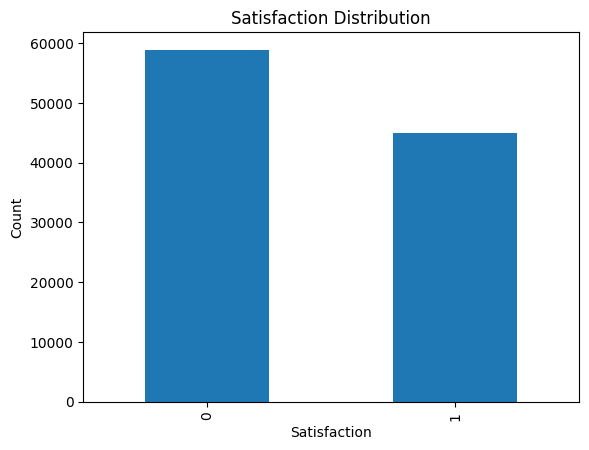

In [24]:
plt.figure()
df['satisfaction'].value_counts().plot(kind='bar')
plt.title("Satisfaction Distribution")
plt.xlabel("Satisfaction")
plt.ylabel("Count")
plt.show()

<Figure size 640x480 with 0 Axes>

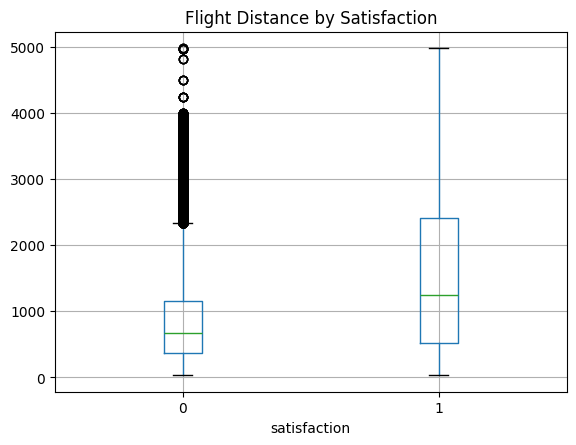

In [26]:
plt.figure()
df.boxplot(column='Flight Distance', by='satisfaction')
plt.title("Flight Distance by Satisfaction")
plt.suptitle("")
plt.show()

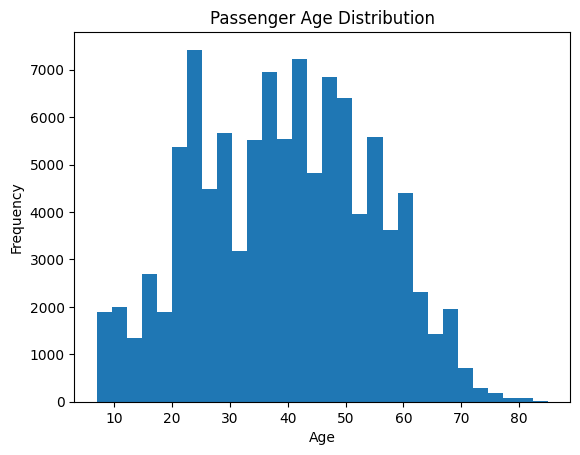

In [27]:
plt.figure()
plt.hist(df['Age'], bins=30)
plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

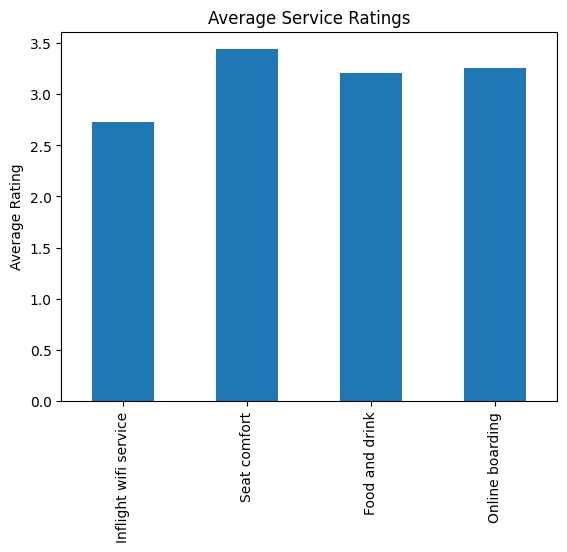

In [28]:
service_means = df[rating_cols].mean()
plt.figure()
service_means.plot(kind='bar')
plt.title("Average Service Ratings")
plt.ylabel("Average Rating")
plt.show()

# **Task 5: Feature Engineering**

In [31]:
df['total_delay'] = (df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes'])

In [32]:
median_distance = df['Flight Distance'].median()
df['long_flight'] = (df['Flight Distance'] > median_distance).astype(int)

In [33]:
categorical_cols = [
    'Gender',
    'Customer Type',
    'Type of Travel',
    'Class'
]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [34]:
from sklearn.preprocessing import StandardScaler
num_cols = [
    'Age',
    'Flight Distance',
    'total_delay'
]
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# **Task 7: Train–Test Split**

In [35]:
y=df['satisfaction']

In [36]:
y

,satisfaction
0,0
1,0
2,1
3,0
4,1
...,...
103899,0
103900,1
103901,0
103902,0


In [39]:
X = df.drop(columns=['satisfaction'])
X

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,total_delay,long_flight,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,70172,-1.745279,-0.731539,3,4,3,1,5,3,5,...,5,25,18.0,0.171470,0,True,False,True,False,True
1,5047,-0.951360,-0.957184,3,2,3,3,1,3,1,...,1,1,6.0,-0.301515,0,True,True,False,False,False
2,110028,-0.885200,-0.047584,2,2,2,2,5,5,5,...,5,0,0.0,-0.393484,1,False,False,False,False,False
3,24026,-0.951360,-0.629246,2,5,5,5,2,2,2,...,2,11,9.0,-0.130715,0,False,False,False,False,False
4,119299,1.430397,-0.978244,3,3,3,3,4,5,5,...,3,0,0.0,-0.393484,0,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,94171,-1.083680,-1.000307,2,1,2,3,2,2,2,...,2,3,0.0,-0.354068,0,False,True,False,True,False
103900,73097,0.636478,1.160869,4,4,4,4,2,4,5,...,4,0,0.0,-0.393484,1,True,False,False,False,False
103901,68825,-0.620561,0.807860,1,1,1,3,4,1,5,...,4,7,14.0,-0.117576,1,True,True,False,False,False
103902,54173,-1.149840,-0.189991,1,1,1,5,1,1,1,...,1,0,0.0,-0.393484,1,False,True,False,True,False


In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

# **Task 8: Classification Modeling**

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [43]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

In [45]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)

In [47]:
def evaluate_model(y_true, y_pred):
    return {"Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)}
results = {"Logistic Regression": evaluate_model(y_test, lr_preds),
    "Random Forest": evaluate_model(y_test, rf_preds),
    "Gradient Boosting": evaluate_model(y_test, gb_preds)}
pd.DataFrame(results)

,Logistic Regression,Random Forest,Gradient Boosting
Accuracy,0.849430,0.963669,0.943554
Precision,0.823369,0.974757,0.947309
Recall,0.833811,0.941112,0.921923
F1-score,0.828557,0.957639,0.934444
